In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/manju/Downloads/U.S._Chronic_Disease_Indicators.csv', low_memory=False)
print(f"Dataset Shape: {df.shape}")

print("\nFirst 5 rows of the data:")
display(df.head())

print("\nColumn Information:")
df.info()

print("\nMissing Values Count:")
print(df.isnull().sum())

print("\nUnique Health Topics in the Dataset:")
print(df['Topic'].unique())

Dataset Shape: (309215, 34)

First 5 rows of the data:


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValu

In [3]:

df_clean = df[(df['Topic'] == 'Diabetes') & 
              (df['DataValueType'] == 'Crude Prevalence')].copy()


cols_to_keep = [
    'YearStart', 'LocationDesc', 'Topic', 'Question', 
    'DataValue', 'DataValueUnit', 'Stratification1'
]
df_clean = df_clean[cols_to_keep]

df_clean.dropna(subset=['DataValue'], inplace=True)

df_clean = df_clean[df_clean['LocationDesc'] != 'United States']

df_clean['DataValue'] = pd.to_numeric(df_clean['DataValue'], errors='coerce')

print(f"Cleaned Dataset Shape: {df_clean.shape}")
print("\nFirst 5 rows of cleaned data:")
display(df_clean.head())

print("\nMissing values in cleaned data:")
print(df_clean.isnull().sum())

Cleaned Dataset Shape: (2582, 7)

First 5 rows of cleaned data:


,YearStart,LocationDesc,Topic,Question,DataValue,DataValueUnit,Stratification1
102,2019,Delaware,Diabetes,Diabetes among adults,15.5,%,Age 45-64
103,2019,Delaware,Diabetes,Gestational diabetes among women with a recent...,12.5,%,"White, non-Hispanic"
122,2019,Guam,Diabetes,Diabetes among adults,10.1,%,Female
150,2019,Iowa,Diabetes,Gestational diabetes among women with a recent...,11.6,%,"Black, non-Hispanic"
289,2019,Pennsylvania,Diabetes,Diabetes among adults,10.6,%,Male



Missing values in cleaned data:
YearStart          0
LocationDesc       0
Topic              0
Question           0
DataValue          0
DataValueUnit      0
Stratification1    0
dtype: int64


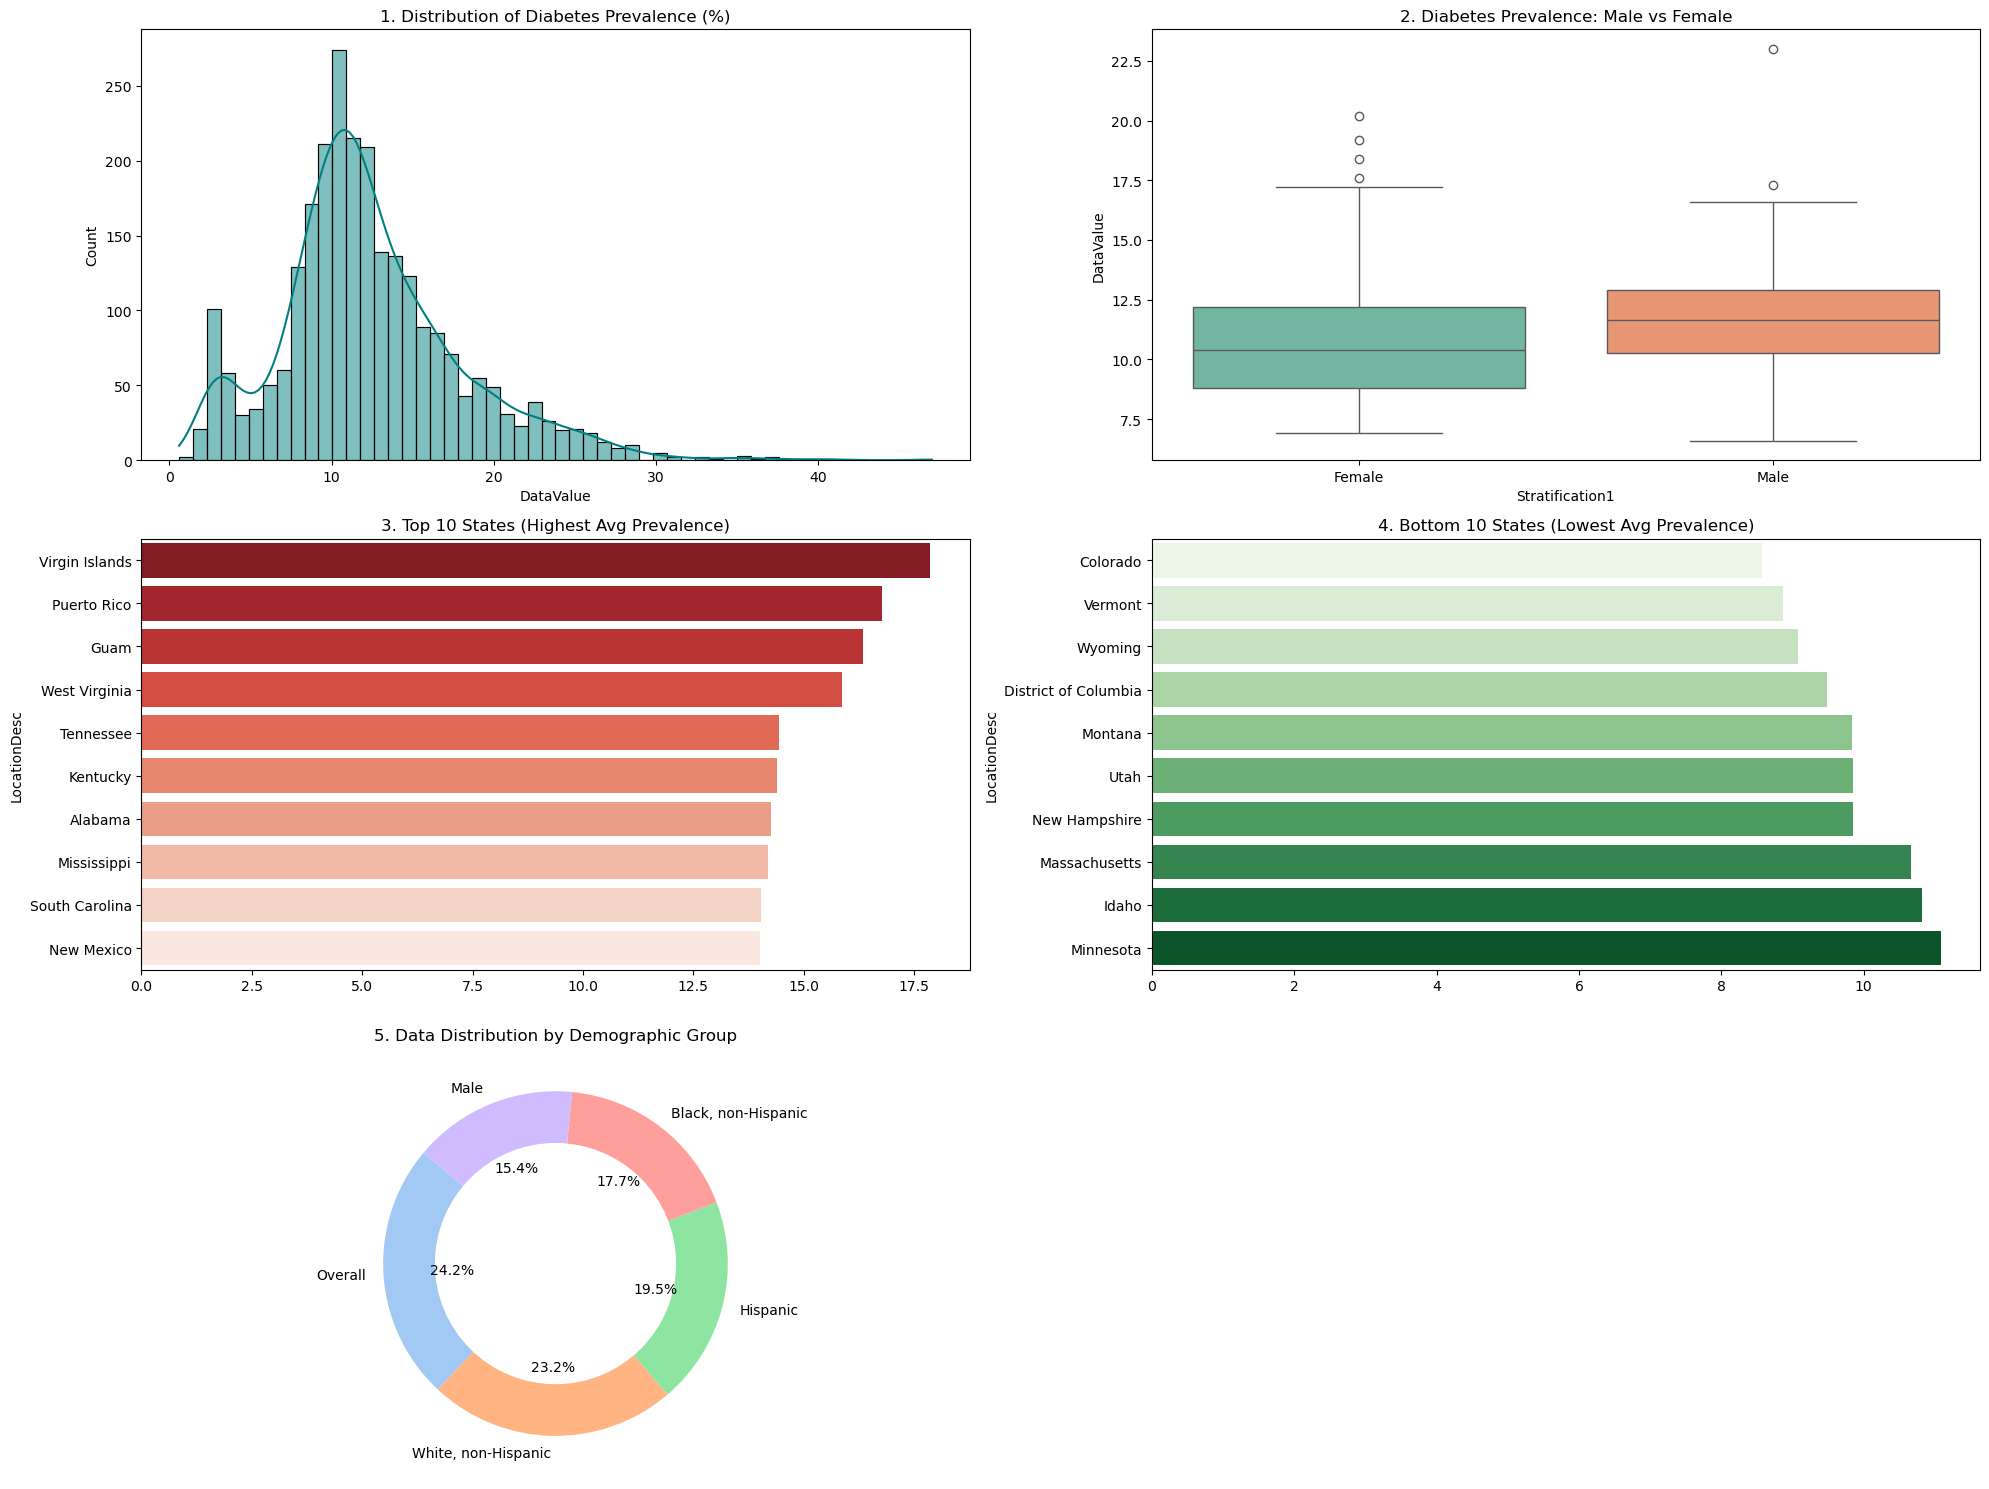

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))

plt.subplot(3, 2, 1)
sns.histplot(df_clean['DataValue'], kde=True, color='teal')
plt.title('1. Distribution of Diabetes Prevalence (%)')

plt.subplot(3, 2, 2)
gender_data = df_clean[df_clean['Stratification1'].isin(['Male', 'Female'])]
sns.boxplot(x='Stratification1', y='DataValue', data=gender_data, hue='Stratification1', palette='Set2', legend=False)
plt.title('2. Diabetes Prevalence: Male vs Female')

plt.subplot(3, 2, 3)
top_10 = df_clean.groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='Reds_r', legend=False)
plt.title('3. Top 10 States (Highest Avg Prevalence)')

plt.subplot(3, 2, 4)
bottom_10 = df_clean.groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=True).head(10)
sns.barplot(x=bottom_10.values, y=bottom_10.index, hue=bottom_10.index, palette='Greens', legend=False)
plt.title('4. Bottom 10 States (Lowest Avg Prevalence)')

plt.subplot(3, 2, 5)
strat_counts = df_clean['Stratification1'].value_counts().head(5)
plt.pie(strat_counts, labels=strat_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('5. Data Distribution by Demographic Group')

plt.tight_layout()
plt.show()

In [15]:
# --- STEP 4 (PART 1): DATA ENCODING ---

from sklearn.preprocessing import LabelEncoder

# 1. Create a fresh copy for the ML part
df_ml = df_clean.copy()

# 2. Initialize the Label Encoder
le_location = LabelEncoder()
le_group = LabelEncoder()
le_question = LabelEncoder()

# 3. Transform the columns
# This turns names into numbers (e.g., Alabama -> 1, Alaska -> 2)
df_ml['Location_Num'] = le_location.fit_transform(df_ml['LocationDesc'])
df_ml['Group_Num'] = le_group.fit_transform(df_ml['Stratification1'])
df_ml['Question_Num'] = le_question.fit_transform(df_ml['Question'])

# 4. Let's look at the result
print("--- ENCODING PREVIEW ---")
# Showing the mapping of the first 5 locations
location_mapping = dict(zip(le_location.classes_, le_location.transform(le_location.classes_)))
print("\nLocation Mapping (First 5):")
for loc in list(location_mapping.keys())[:5]:
    print(f"{loc} -> {location_mapping[loc]}")

print("\n--- NEW DATA FRAME COLUMNS ---")
display(df_ml[['LocationDesc', 'Location_Num', 'Stratification1', 'Group_Num', 'DataValue']].head())

--- ENCODING PREVIEW ---

Location Mapping (First 5):
Alabama -> 0
Alaska -> 1
Arizona -> 2
Arkansas -> 3
California -> 4

--- NEW DATA FRAME COLUMNS ---


,LocationDesc,Location_Num,Stratification1,Group_Num,DataValue
102,Delaware,7,Age 45-64,1,15.5
103,Delaware,7,"White, non-Hispanic",12,12.5
122,Guam,11,Female,6,10.1
150,Iowa,16,"Black, non-Hispanic",5,11.6
289,Pennsylvania,39,Male,9,10.6


--- MODEL REPORT CARD ---
R-Squared (Accuracy): 73.34%
Mean Absolute Error: 1.80%
Root Mean Squared Error: 2.88%


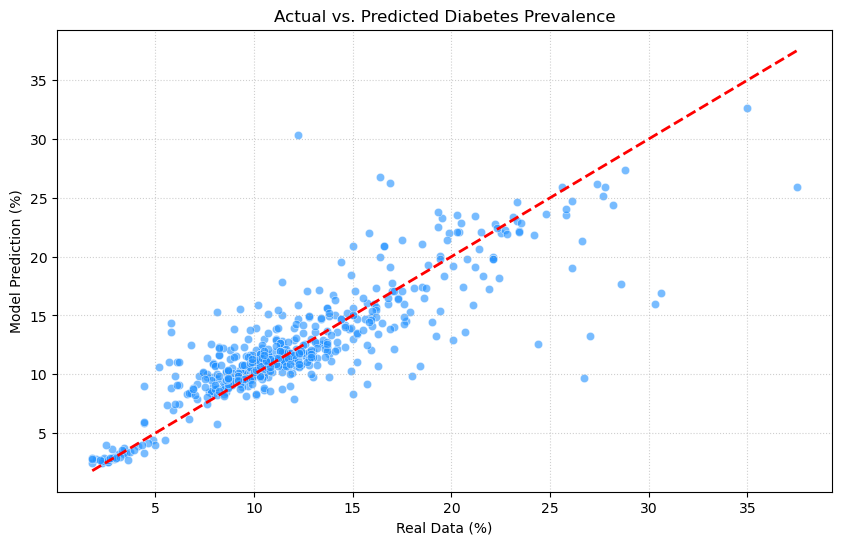

In [19]:
# --- FIXED STEP 4 (PART 2 & 3 COMBINED) ---
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. THE PREDICTION STEP (This defines 'y_pred')
# If you don't run this line, the computer doesn't have any guesses to check!
y_pred = model.predict(X_test)

# 2. CALCULATE THE ACCURACY SCORES
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- MODEL REPORT CARD ---")
print(f"R-Squared (Accuracy): {r2*100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f}%")
print(f"Root Mean Squared Error: {rmse:.2f}%")

# 3. VISUALIZATION: Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='dodgerblue')

# The "Perfect Prediction" Line (Red Dashed)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted Diabetes Prevalence')
plt.xlabel('Real Data (%)')
plt.ylabel('Model Prediction (%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

--- DECISION TREE REPORT CARD ---
R-Squared Accuracy: 52.49%
Mean Absolute Error: 2.66%


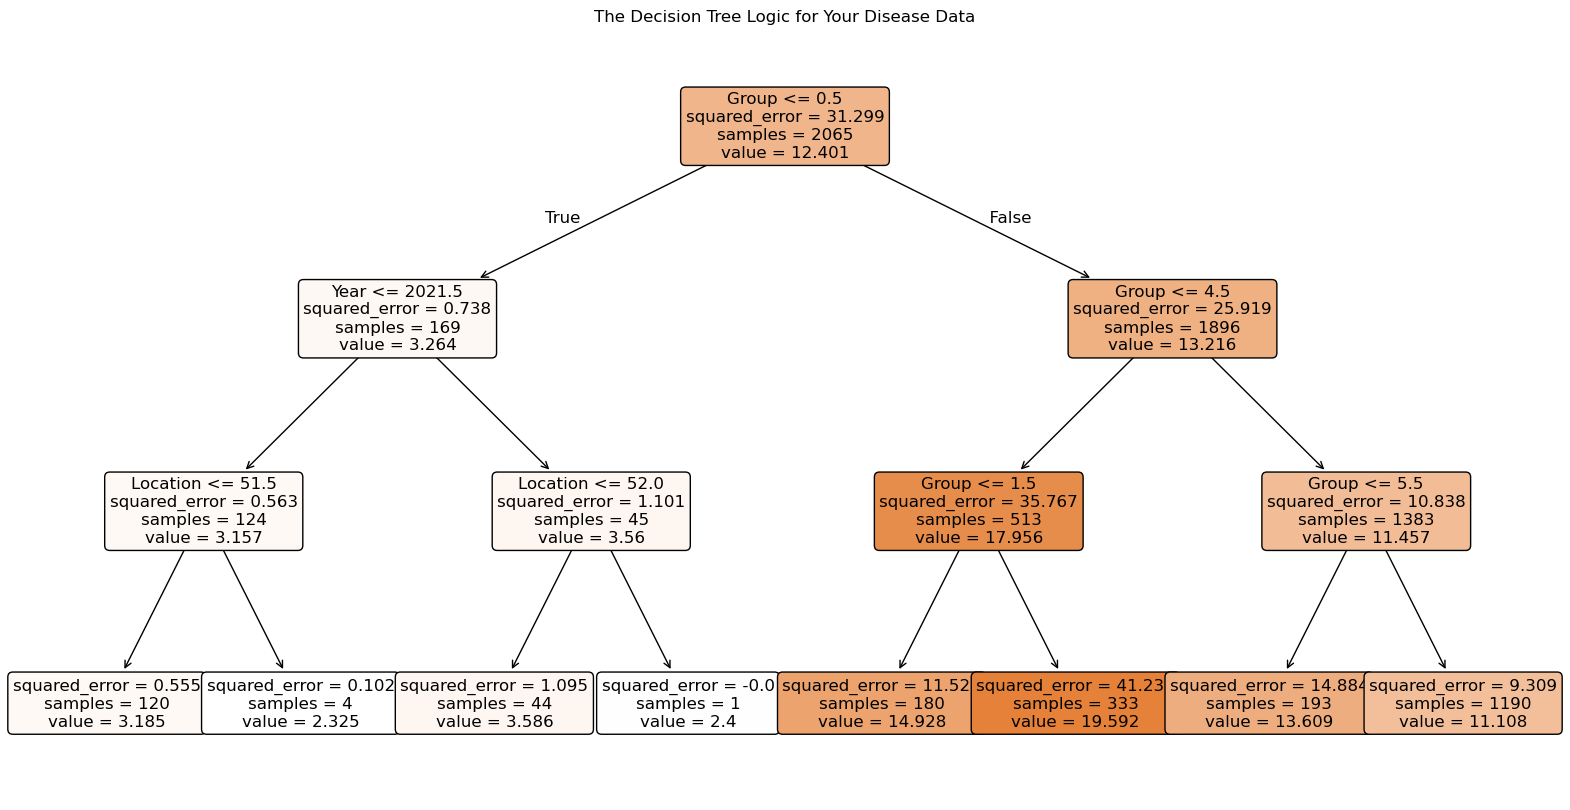

In [21]:
# --- STEP 4 (PART 4): APPLYING A SINGLE DECISION TREE ---
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Initialize the Decision Tree
# We set max_depth=3 so the tree is small enough to see and understand
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)

# 2. Train the model
dt_model.fit(X_train, y_train)

# 3. Make predictions
dt_preds = dt_model.predict(X_test)

# 4. Check Accuracy
dt_r2 = r2_score(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)

print("--- DECISION TREE REPORT CARD ---")
print(f"R-Squared Accuracy: {dt_r2*100:.2f}%")
print(f"Mean Absolute Error: {dt_mae:.2f}%")

# 5. VISUALIZE THE TREE (The Flowchart)
plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=['Year', 'Location', 'Group', 'Question'], 
          filled=True, 
          fontsize=12,
          rounded=True)
plt.title("The Decision Tree Logic for Your Disease Data")
plt.show()

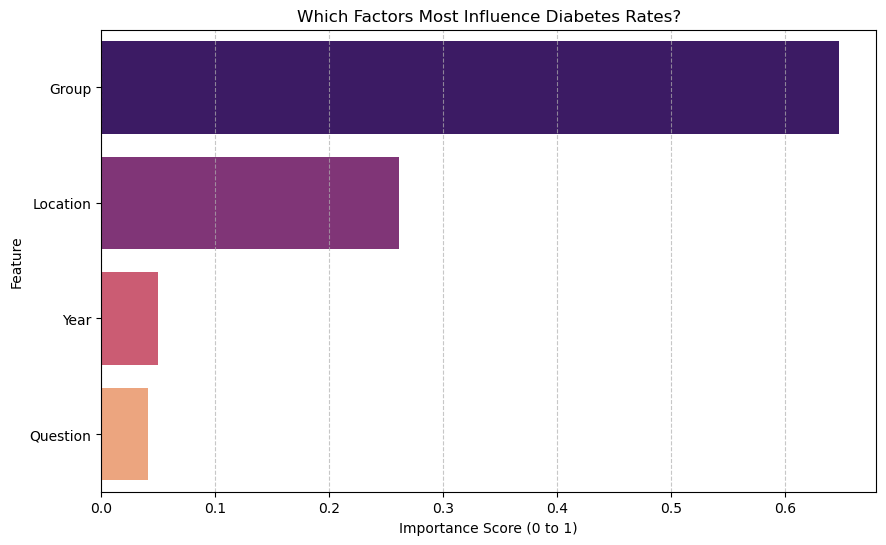

--- FEATURE RANKING ---
Group: 0.6475
Location: 0.2616
Year: 0.0500
Question: 0.0409


In [23]:
# --- STEP 4 (PART 5): FEATURE IMPORTANCE ---

# 1. Get the importance scores from the Random Forest model
importances = model.feature_importances_
feature_names = ['Year', 'Location', 'Group', 'Question']

# 2. Organize them into a DataFrame for plotting
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Plotting (Similar to the bar charts in the video)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='magma', legend=False)

plt.title('Which Factors Most Influence Diabetes Rates?')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Print the results for clarity
print("--- FEATURE RANKING ---")
for index, row in feature_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

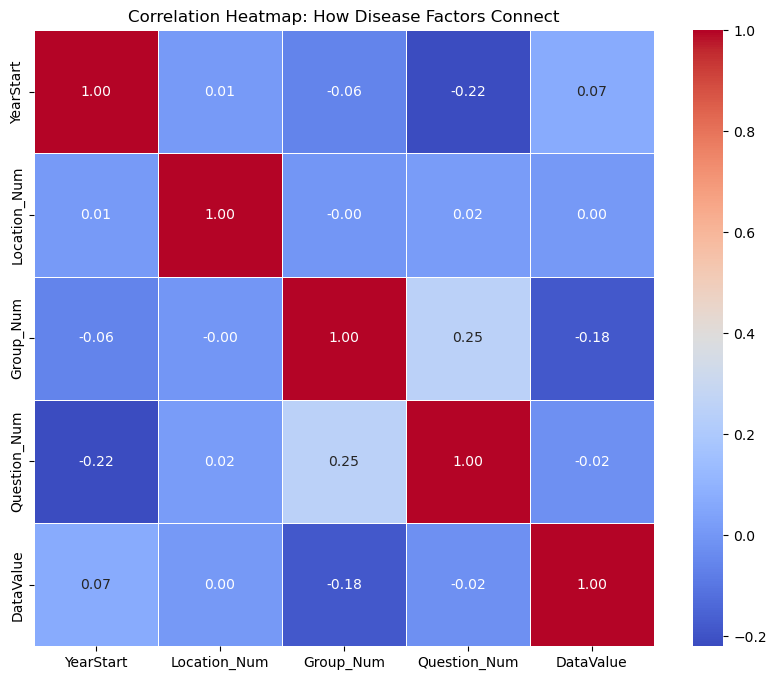

In [25]:
# --- STEP 4 (PART 6): CORRELATION HEATMAP ---

# 1. Select only the numerical columns for correlation
# We use our encoded columns (Location_Num, Group_Num) and the DataValue
corr_df = df_ml[['YearStart', 'Location_Num', 'Group_Num', 'Question_Num', 'DataValue']]

# 2. Calculate the correlation matrix
correlation_matrix = corr_df.corr()

# 3. Create the Heatmap (Just like professional EDA)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: How Disease Factors Connect')
plt.show()

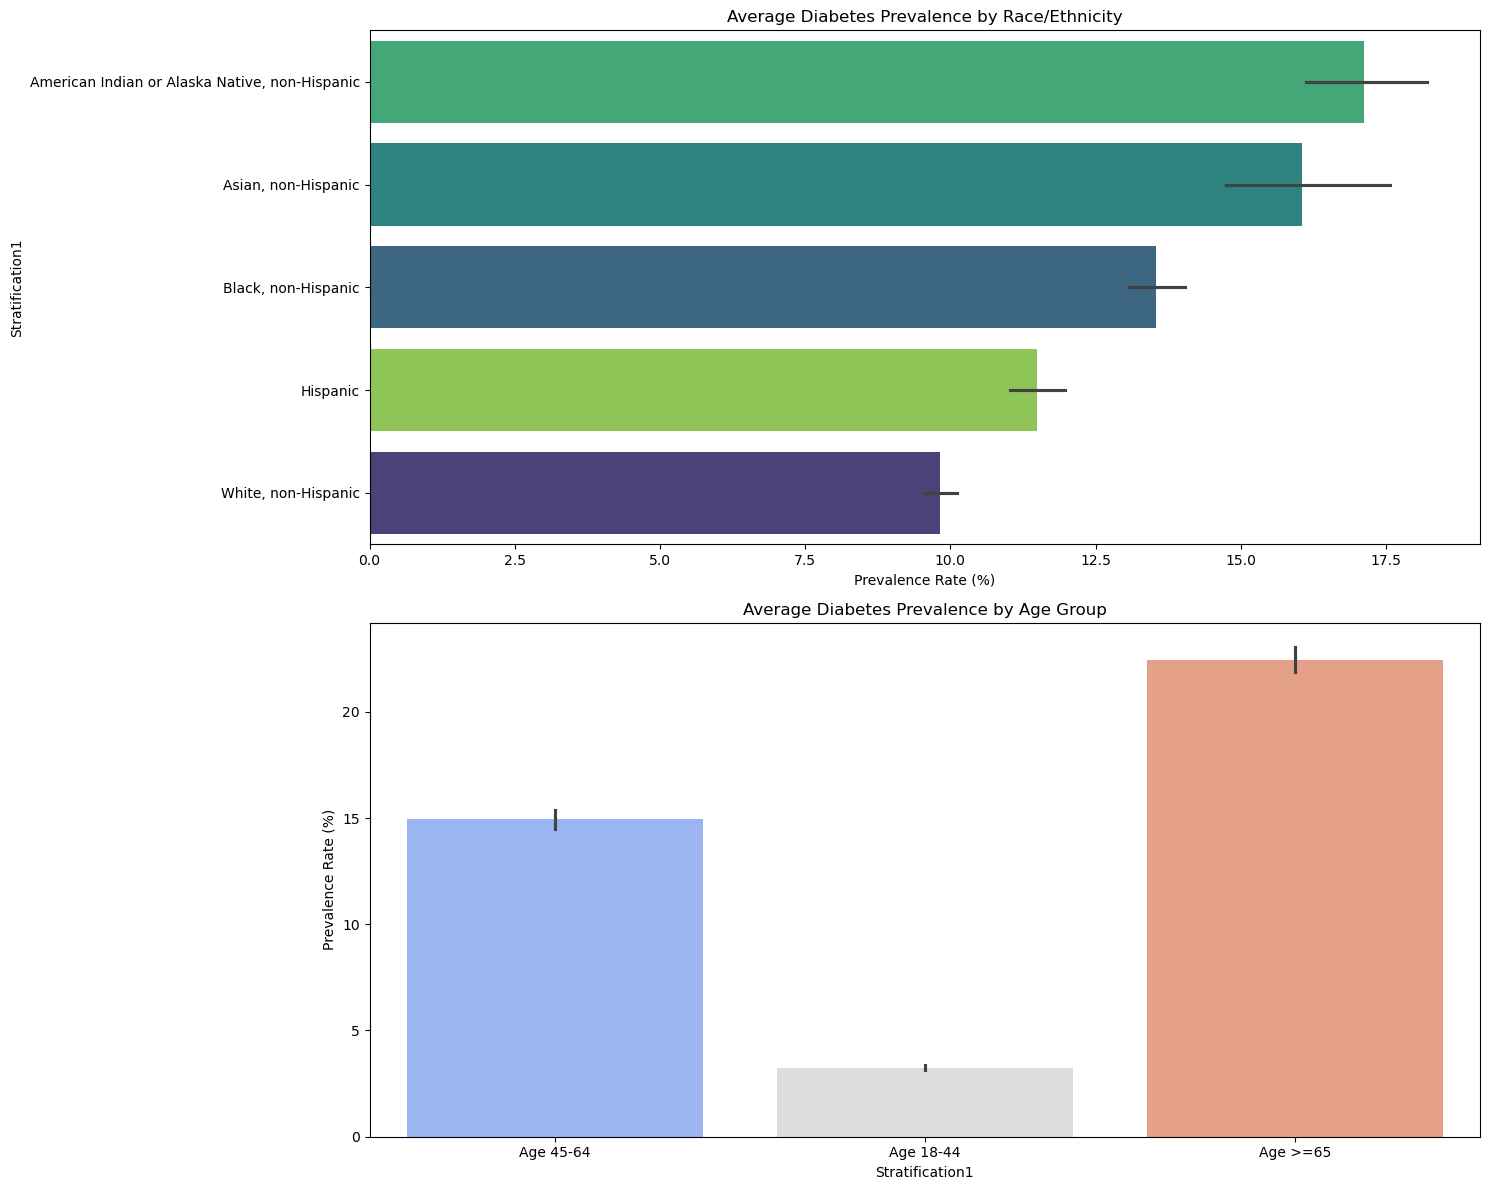

In [27]:
# --- STEP 3 (PART 5): CATEGORICAL COMPARISON ---

# 1. Create a figure for multiple comparisons
plt.figure(figsize=(15, 12))

# CHART A: Breakdown by Race/Ethnicity
plt.subplot(2, 1, 1)
# Filtering for common race categories in your data
race_groups = ['White, non-Hispanic', 'Black, non-Hispanic', 'Hispanic', 
               'Asian, non-Hispanic', 'American Indian or Alaska Native, non-Hispanic']
df_race = df_clean[df_clean['Stratification1'].isin(race_groups)]

# Group and Plot
race_order = df_race.groupby('Stratification1')['DataValue'].mean().sort_values(ascending=False).index
sns.barplot(x='DataValue', y='Stratification1', data=df_race, order=race_order, palette='viridis', hue='Stratification1', legend=False)
plt.title('Average Diabetes Prevalence by Race/Ethnicity')
plt.xlabel('Prevalence Rate (%)')

# CHART B: Breakdown by Age Group
plt.subplot(2, 1, 2)
age_groups = ['Age 18-44', 'Age 45-64', 'Age >=65']
df_age = df_clean[df_clean['Stratification1'].isin(age_groups)]

# Group and Plot
sns.barplot(x='Stratification1', y='DataValue', data=df_age, palette='coolwarm', hue='Stratification1', legend=False)
plt.title('Average Diabetes Prevalence by Age Group')
plt.ylabel('Prevalence Rate (%)')

plt.tight_layout()
plt.show()

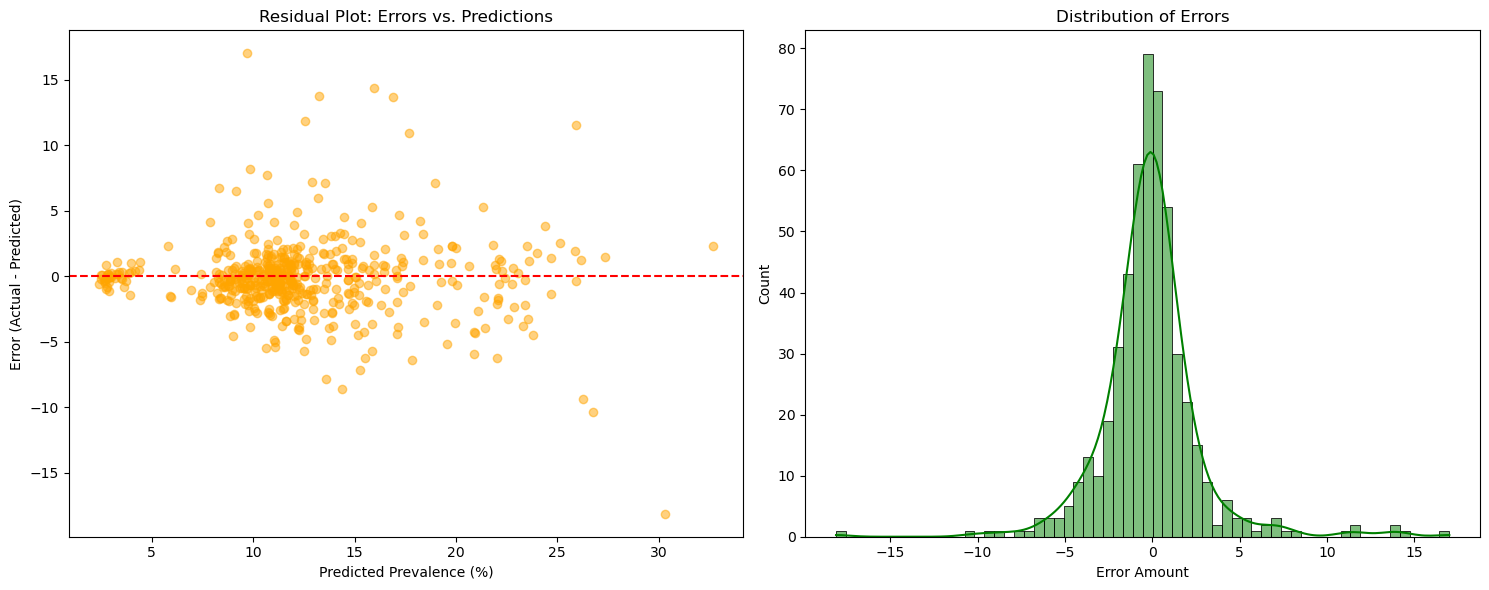

In [29]:
# --- STEP 4 (PART 7): RESIDUAL ANALYSIS ---

# 1. Calculate the Residuals
residuals = y_test - y_pred

# 2. Create a 2-plot layout
plt.figure(figsize=(15, 6))

# Plot 1: Residual Scatter Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5, color='orange')
plt.axhline(y=0, color='red', linestyle='--') # The "Zero Error" line
plt.title('Residual Plot: Errors vs. Predictions')
plt.xlabel('Predicted Prevalence (%)')
plt.ylabel('Error (Actual - Predicted)')

# Plot 2: Histogram of Residuals (Error Distribution)
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribution of Errors')
plt.xlabel('Error Amount')

plt.tight_layout()
plt.show()